This notebook is to help construct the necessary attributes file that will be inputted to the various tested clustering methods. The output file will be a csv called UKR_attributes. 

In [1]:
import geopandas as gpd
from rasterstats import zonal_stats
import pandas as pd
import numpy as np

# File paths
geojson_path = "data/UKR_solar_power_profile_trimmed.geojson"
raster_path = "data/WorldPop_Ukraine/ukr_pop_2023_new_download.tif"
output_csv = "data/UKR_population_per_cell.csv"

# Load cells with their exact polygon geometries
print("Loading GeoJSON...")
cells_gdf = gpd.read_file(geojson_path)
print(f"  Loaded {len(cells_gdf)} cells with {cells_gdf.geometry.type.unique()} geometries")

# Extract population using the exact cell polygons
print("\nExtracting population from raster...")
stats = zonal_stats(
    vectors=cells_gdf.geometry,
    raster=raster_path,
    stats=["sum"],
    nodata=np.nan,
    all_touched=True
)

cells_gdf["population"] = [s["sum"] if s["sum"] is not None else 0 for s in stats]

# Convert to integers
cells_gdf["population"] = cells_gdf["population"].round().astype(int)

# Save
result = cells_gdf[["location", "population"]].copy()
# result.to_csv(output_csv, index=False)

print(f"\nResults saved to {output_csv}")
print(f"Total population: {result['population'].sum():,.0f}")
print(result[result["population"] > 0].head())


Loading GeoJSON...
  Loaded 1180 cells with ['Polygon'] geometries

Extracting population from raster...

Results saved to data/UKR_population_per_cell.csv
Total population: 37,474,543
      location  population
0  44.50_33.75       31937
1  44.50_34.00       49077
2  44.75_33.75       60841
3  44.75_34.00       23314
4  44.75_34.25       15075


In [2]:
# I want to create a csv that gets the mean and standard deviation of solar_cf and wind_cf for each cell.

# Load solar and wind timeseries data
solar_path = "era5_data/UKR_solar_power_profile_trimmed.csv"
wind_path = "era5_data/UKR_wind_power_profile_trimmed.csv"

# Read timeseries data (first column is datetime, then locations)
solar_ts = pd.read_csv(solar_path, index_col=0, parse_dates=True)
wind_ts = pd.read_csv(wind_path, index_col=0, parse_dates=True)

# Calculate mean and std for each location (column)
cf_stats = pd.DataFrame({
    "location": solar_ts.columns,
    "solar_cf_mean": solar_ts.mean().values,
    "solar_cf_std": solar_ts.std().values,
    "wind_cf_mean": wind_ts.mean().values,
    "wind_cf_std": wind_ts.std().values
})

# Save to CSV
output_stats_csv = "data/UKR_cf_stats.csv"
# cf_stats.to_csv(output_stats_csv, index=False)

print(f"Results saved to {output_stats_csv}")
print(cf_stats.head())

Results saved to data/UKR_cf_stats.csv
      location  solar_cf_mean  solar_cf_std  wind_cf_mean  wind_cf_std
0  44.50_33.75       0.153579      0.222195      0.134964     0.204923
1  44.50_34.00       0.156607      0.223476      0.094387     0.158113
2  44.75_33.75       0.151316      0.219372      0.166987     0.230832
3  44.75_34.00       0.154335      0.221104      0.109712     0.167763
4  44.75_34.25       0.157591      0.223659      0.107819     0.174405


In [3]:
# I want to create an attrbutes file that has lon, lat, wind_cf, solar_cf, area, available_land_area, availability_fraction, pc1, pc2, pc3,pop_sum

availability_path = 'data/UKR_renewables_land_cover_with_offshore_trimmed.csv'
pc_path = 'data/UKR_wind_solar_PCs_trimmed.csv'
availability_df = pd.read_csv(availability_path)
pc_df = pd.read_csv(pc_path)

attributes_df = availability_df[["location", "area_km2", "available_land_fraction", "available_land_area_km2"]].copy()
attributes_df = attributes_df.merge(cf_stats, on="location", how="left")
attributes_df = attributes_df.merge(result, on="location", how="left")
attributes_df = attributes_df.merge(pc_df, on="location", how="left")

# Split location
loc_split = attributes_df["location"].str.split("_", expand=True).astype(float)
attributes_df["lat"] = loc_split[0]
attributes_df["lon"] = loc_split[1]

attributes_df = attributes_df[["lon", "lat", "area_km2", "available_land_fraction", "available_land_area_km2",
                               "solar_cf_mean", "solar_cf_std", "wind_cf_mean", "wind_cf_std", "population", "pc1", "pc2", "pc3"]]

# Save combined attributes
# output_attributes_csv = "data/UKR_attributes.csv"
# attributes_df.to_csv(output_attributes_csv, index=False)
# print(f"Combined attributes saved to {output_attributes_csv}")
# print(attributes_df.head())

In [4]:
# Add average power demand per cell

# Load national hourly demand data
national_demand_path = '../data_prep/data/time_series_60min_singleindex.csv'

print(f"   Loading national demand from: {national_demand_path}")
national_df = pd.read_csv(national_demand_path, parse_dates=['utc_timestamp'], low_memory=False)

# Select and rename columns
national_df = national_df[['utc_timestamp', 'UA_load_actual_entsoe_transparency']].copy()
national_df.rename(columns={
    'utc_timestamp': 'datetime',
    'UA_load_actual_entsoe_transparency': 'national_MWh'
}, inplace=True)

# Clean and remove timezone info to match wind/solar index
national_df['datetime'] = pd.to_datetime(national_df['datetime'], errors='coerce')
national_df['datetime'] = national_df['datetime'].dt.tz_localize(None)  # Remove UTC timezone
national_df = national_df.dropna(subset=['datetime', 'national_MWh']).reset_index(drop=True)

# Filter to 2023 to match wind/solar profiles
target_year = 2023
print(f"   Filtering national demand to year {target_year}...")

# If 2023 data doesn't exist, use 2019 data and shift the year
available_years = national_df['datetime'].dt.year.unique()
print(f"   Available years in national demand: {sorted(available_years)}")

if target_year in available_years:
    national_df = national_df[national_df['datetime'].dt.year == target_year].reset_index(drop=True)
else:
    # Use 2019 data and shift to target year
    print(f"   {target_year} not available, using 2019 pattern and shifting to {target_year}")
    national_df = national_df[national_df['datetime'].dt.year == 2019].reset_index(drop=True)
    national_df['datetime'] = national_df['datetime'].apply(lambda t: t.replace(year=target_year))

# Set datetime as index (now timezone-naive, matching wind/solar)
national_df = national_df.set_index('datetime')

# Calculate total national energy (MWh)
national_total_MWh = national_df['national_MWh'].sum()

print(len(national_df), "hourly demand records loaded for year", target_year)

national_df = national_df.reindex(wind_ts.index, method='nearest')

Total_demand_MWh = national_df['national_MWh'].sum()
print(f"Total national demand for {target_year}: {Total_demand_MWh:,.0f} MWh")

attributes_df['population_fraction'] = attributes_df['population'] / attributes_df['population'].sum()
attributes_df['demand_MWh'] = attributes_df['population_fraction'] * Total_demand_MWh

ammonia_data = pd.read_csv('data/UKR_ammonia_point_demand.csv',index_col=False)
attributes_df = attributes_df.merge(ammonia_data, on=["lat", "lon"], how="left")
attributes_df = attributes_df[["lon", "lat", "area_km2", "available_land_fraction", "available_land_area_km2",
                               "solar_cf_mean", "solar_cf_std", "wind_cf_mean", "wind_cf_std", "pc1", "pc2", "pc3", "population","population_fraction", "demand_MWh", "ammonia_demand_tonne", "ammonia_demand_mwh"]]

print(attributes_df['ammonia_demand_tonne'].unique())
attributes_df['ammonia_demand_tonne'] = pd.to_numeric(attributes_df['ammonia_demand_tonne'], errors='coerce').fillna(0)
attributes_df['ammonia_demand_mwh'] = pd.to_numeric(attributes_df['ammonia_demand_mwh'], errors='coerce').fillna(0)


# attributes_df['avg_equiv_demand_MWh'] = (attributes_df['demand_MWh'] + attributes_df['ammonia_demand_mwh'])/len(attributes_df) This is what this was originally, but I think it makes more sense to divide by 8760 to get an average hourly demand per cell, rather than dividing by the number of cells.
# All my results used the above but for plotting average hourly demand per cell, I think it makes more sense to divide by 8760 (hours in a year) rather than the number of cells, since the demand is an annual total. So I will change this to:
attributes_df['avg_equiv_demand_MWh'] = (attributes_df['demand_MWh'] + attributes_df['ammonia_demand_mwh'])/8760

print(attributes_df.head())
attributes_df.to_csv("data/UKR_attributes_3.csv", index=False)



   Loading national demand from: ../data_prep/data/time_series_60min_singleindex.csv
   Filtering national demand to year 2023...
   Available years in national demand: [np.int32(2017), np.int32(2018), np.int32(2019), np.int32(2020)]
   2023 not available, using 2019 pattern and shifting to 2023
8349 hourly demand records loaded for year 2023
Total national demand for 2023: 149,187,992 MWh
[      nan 997483.8  774658.79 337857.42]
     lon    lat    area_km2  available_land_fraction  available_land_area_km2  \
0  33.75  44.50  552.342336                 0.126063                69.630118   
1  34.00  44.50  552.342336                 0.084361                46.596197   
2  33.75  44.75  550.000972                 0.176959                97.327661   
3  34.00  44.75  550.000972                 0.119070                65.488524   
4  34.25  44.75  550.000972                 0.161060                88.583320   

   solar_cf_mean  solar_cf_std  wind_cf_mean  wind_cf_std        pc1  \
0     

In [8]:
top5_cells = attributes_df.nsmallest(5, 'avg_equiv_demand_MWh')
print("Top 5 cells smallest by average equivalent demand:")
for idx, row in top5_cells.iterrows():
    print(f"  {idx}: lat={row['lat']}, lon={row['lon']}, avg_equiv_demand_MWh={row['avg_equiv_demand_MWh']:.2f}")

Top 5 cells smallest by average equivalent demand:
  1085: lat=51.25, lon=30.25, avg_equiv_demand_MWh=0.00
  71: lat=46.25, lon=31.75, avg_equiv_demand_MWh=0.01
  1086: lat=51.25, lon=30.5, avg_equiv_demand_MWh=0.03
  234: lat=47.75, lon=25.0, avg_equiv_demand_MWh=0.08
  1084: lat=51.25, lon=30.0, avg_equiv_demand_MWh=0.08


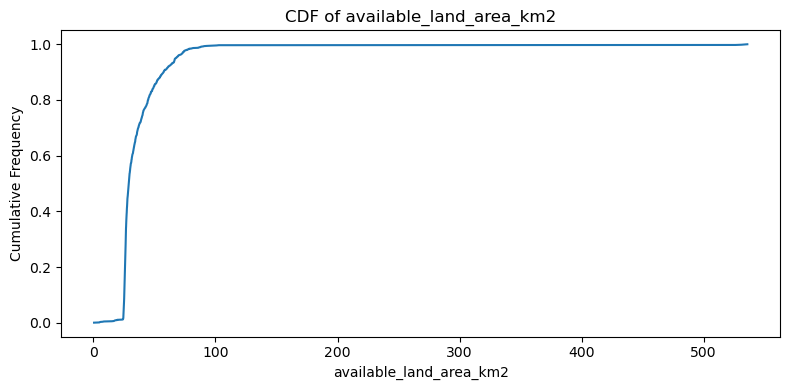

In [2]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("data/UKR_attributes_3.csv")

fig, ax = plt.subplots(figsize=(8, 4))
sorted_vals = df["available_land_area_km2"].sort_values()
cdf = (sorted_vals.rank(method="max") / len(sorted_vals))
ax.plot(sorted_vals.values, cdf.values)
# ax.set_xscale('log') --- IGNORE ---
ax.set_xlabel("available_land_area_km2")
ax.set_ylabel("Cumulative Frequency")
ax.set_title("CDF of available_land_area_km2")
plt.tight_layout()
plt.show()